In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

df = pd.read_csv('../results/HELMSamplesLabeled.csv')

metrics = ['stats_bleu_4', 'stats_f1_score', 'bleu_complete', 'f1_complete', 'Vee','Eee','Ven','Een']

In [ ]:
def get_spearman(metrics, df):
    corrs = []
    for m in metrics:
        if m in df:
            corr = df[[m,'label']].corr(method='spearman').iloc[0,1]
            corrs.append((m, corr))
    return corrs

def get_auroc(metrics, df):
    results = []
    for m in metrics:
        if m not in df.columns:
            continue
        
        tmp = df[['label', m]].dropna()
        if tmp[m].nunique() <= 1:
            continue  
    
        y = tmp['label']
        x = tmp[m].astype(float)
    
        auc = roc_auc_score(y, x)
        ap  = average_precision_score(y, x)
    
        results.append((m, auc, ap))
    return results

def get_unbalanced_acc(metrics, df):
    accs = []
    for m in metrics:
        if m in df:
            tmp = df[['label', m]].dropna()
            acc = (tmp['label'] == tmp[m]).mean()
            accs.append((m, acc))
    return accs

def get_balanced_acc(metrics, df, length=1000):
    res = []
    for m in metrics:
        if m in df:
            tmp_accs = []
            tmp_thresholds = []
            for x in range(length):
                SEED = x

                tmp = df[df[m].notna()]
                min_count = tmp['label'].value_counts().min()
                
                tmp_balanced = (tmp.groupby('label', group_keys=False).apply(lambda x: x.sample(min_count, random_state=SEED)).reset_index(drop=True))
                scores = tmp_balanced[m].values
                labels = tmp_balanced["label"].values
                
                thresholds = np.sort(np.unique(scores))
                accuracies = [(labels == (scores >= t)).mean() for t in thresholds]
                
                best_idx = np.argmax(accuracies)
                best_threshold = thresholds[best_idx]
                best_accuracy = accuracies[best_idx]
                tmp_accs.append(best_accuracy)
                tmp_thresholds.append(best_threshold)
            res.append((m, np.mean(tmp_accs), np.std(tmp_accs), np.mean(tmp_thresholds), np.std(tmp_thresholds)))
    return res

In [ ]:
import ast
import re
import string
from collections import Counter
import sacrebleu


def extract_ref(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return x[0]['output']['text']


def normalize_text(s):
    s = str(s).lower()
    s = ''.join(ch for ch in s if ch not in string.punctuation)
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = ' '.join(s.split())
    return s


def token_f1(pred, ref):
    pred_tokens = normalize_text(pred).split()
    ref_tokens = normalize_text(ref).split()

    if len(pred_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(ref_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(ref_tokens)
    return 2 * precision * recall / (precision + recall)

df['bleu_complete'] = np.nan
df['f1_complete'] = np.nan

mask = df['predicted_text'].notna()
tmp = df.loc[mask].copy()
tmp['ref'] = tmp['references'].apply(extract_ref)

tmp['bleu_complete'] = [
    sacrebleu.sentence_bleu(pred, [ref]).score
    for pred, ref in zip(tmp['predicted_text'], tmp['ref'])
]

tmp['f1_complete'] = [
    token_f1(pred, ref)
    for pred, ref in zip(tmp['predicted_text'], tmp['ref'])
]

df['bleu_complete'] = tmp['bleu_complete']
df['bleu_complete'] = df['bleu_complete']/100
df['f1_complete'] = tmp['f1_complete']

In [ ]:
bleu_thresholds = [0.05, 0.1, 0.2, 0.3, 0.4]
f1_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

combs = []

for tb in bleu_thresholds:
    for tf in f1_thresholds:
        or_col = ((df["bleu_complete"] >= tb) | (df["f1_complete"] >= tf)).astype(int)
        and_col = ((df["bleu_complete"] >= tb) & (df["f1_complete"] >= tf)).astype(int)
        rule_name_or = 'or_' + str(tb) + '_' + str(tf)
        rule_name_and = 'and_' + str(tb) + '_' + str(tf)
        df[rule_name_or] = or_col
        df[rule_name_and] = and_col
        combs.append(rule_name_or)
        combs.append(rule_name_and)

alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for alpha in alphas:
    name = 'alpha_' + str(alpha) 
    df[name] = alpha * df["f1_complete"] + (1 - alpha) * df["bleu_complete"]
    combs.append(name)

df["combo_max"] = df[["bleu_complete", "f1_complete"]].max(axis=1)
df["combo_min"] = df[["bleu_complete", "f1_complete"]].min(axis=1)

combs.append('combo_max')
combs.append('combo_min')

In [ ]:
both = metrics + combs
spearman = get_spearman(both, df) #[m, score]
auroc = get_auroc(both, df) #[m, score, ...]
unbal_acc = get_unbalanced_acc(both, df) #[m, score]
bal_acc = get_balanced_acc(both, df, 100) #[m, score, std, threshold, std]

In [ ]:
df_spearman = pd.DataFrame(spearman, columns=["metric", "spearman"])
df_auroc = pd.DataFrame(auroc, columns=["metric", "auroc", "tmp"])
df_unbal = pd.DataFrame(unbal_acc, columns=["metric", "unbal_acc"])
df_bal = pd.DataFrame(
    bal_acc,
    columns=["metric", "bal_acc", "bal_acc_std", "threshold", "threshold_std"]
)

result = (
    df_spearman
    .merge(df_auroc, on="metric", how="outer")
    .merge(df_unbal, on="metric", how="outer")
    .merge(df_bal, on="metric", how="outer")
)

In [91]:
pd.set_option("display.max_rows", None)
result.sort_values('spearman', ascending=False)

,metric,spearman,auroc,tmp,unbal_acc,bal_acc,bal_acc_std,threshold,threshold_std
1,Een,0.625191,0.839302,0.947876,0.895050,0.838933,0.009909,1.000000,0.000000
90,or_0.3_0.2,0.574091,0.807558,0.937898,0.883168,0.806933,0.010767,1.000000,0.000000
99,or_0.4_0.2,0.574091,0.807558,0.937898,0.883168,0.806933,0.010767,1.000000,0.000000
81,or_0.2_0.2,0.569129,0.804225,0.936859,0.882178,0.803600,0.010767,1.000000,0.000000
63,or_0.05_0.2,0.568895,0.802054,0.936160,0.883168,0.801567,0.010630,1.000000,0.000000
72,or_0.1_0.2,0.566514,0.801473,0.935991,0.882178,0.800900,0.010738,1.000000,0.000000
89,or_0.3_0.1,0.559141,0.778023,0.928606,0.889109,0.777933,0.008829,1.000000,0.000000
98,or_0.4_0.1,0.559141,0.778023,0.928606,0.889109,0.777933,0.008829,1.000000,0.000000
108,stats_f1_score,0.557036,0.897056,0.969891,0.490000,0.842719,0.015971,0.389860,0.115819
80,or_0.2_0.1,0.553992,0.774690,0.927593,0.888119,0.774600,0.008829,1.000000,0.000000


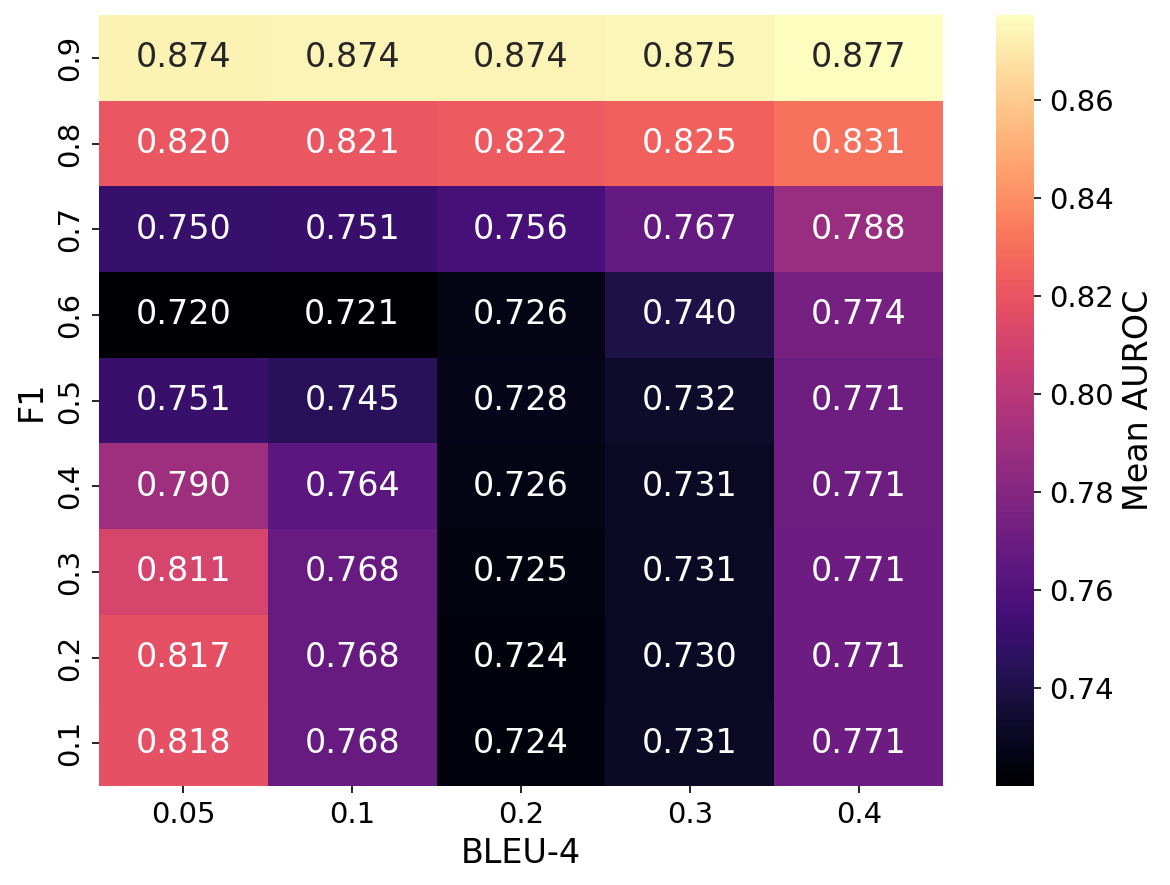

In [83]:
#AND
from glob import glob
import sys
sys.path.append('../src')
import helper

folders = glob('../rebuttal/*/and*')

res = []
for folder in folders:
    model = folder.split('/')[-2]
    comb = folder.split('/')[-1]
    bleu = comb.split('_')[1]
    f1 = comb.split('_')[2]
    try:
        logits = np.load(f'{folder}/logits.npy')
        labels = np.load(f'{folder}/labels.npy')
        m = helper.compute_eval_metrics(logits, labels)
    
        res.append((model, comb, bleu, f1, m['auroc'], m['aupr'], m['brier']))
    except:
        continue

res_df = pd.DataFrame(res, columns=['model', 'comb', 'bleu', 'f1', 'auroc','aupr','brier'])

pivot = res_df.pivot_table(index="f1", columns="bleu", values="auroc", aggfunc="mean")
pivot = pivot.sort_index(ascending=False)

plt.figure(figsize=(8,6), dpi=150)
ax = sns.heatmap(
    pivot,
    annot=True,      
    fmt=".3f",      
    cmap=sns.color_palette("magma", as_cmap=True),
    cbar_kws={"label": "Mean AUROC"},
    annot_kws={"size": 16}
)

cbar = ax.collections[0].colorbar
cbar.set_label("Mean AUROC", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.xlabel("BLEU-4", fontsize=16)
plt.ylabel("F1", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig("../results/figures/Rebuttal_Barrier1_and_combination.pdf", dpi=300, pad_inches=0.0, bbox_inches="tight")
plt.show()

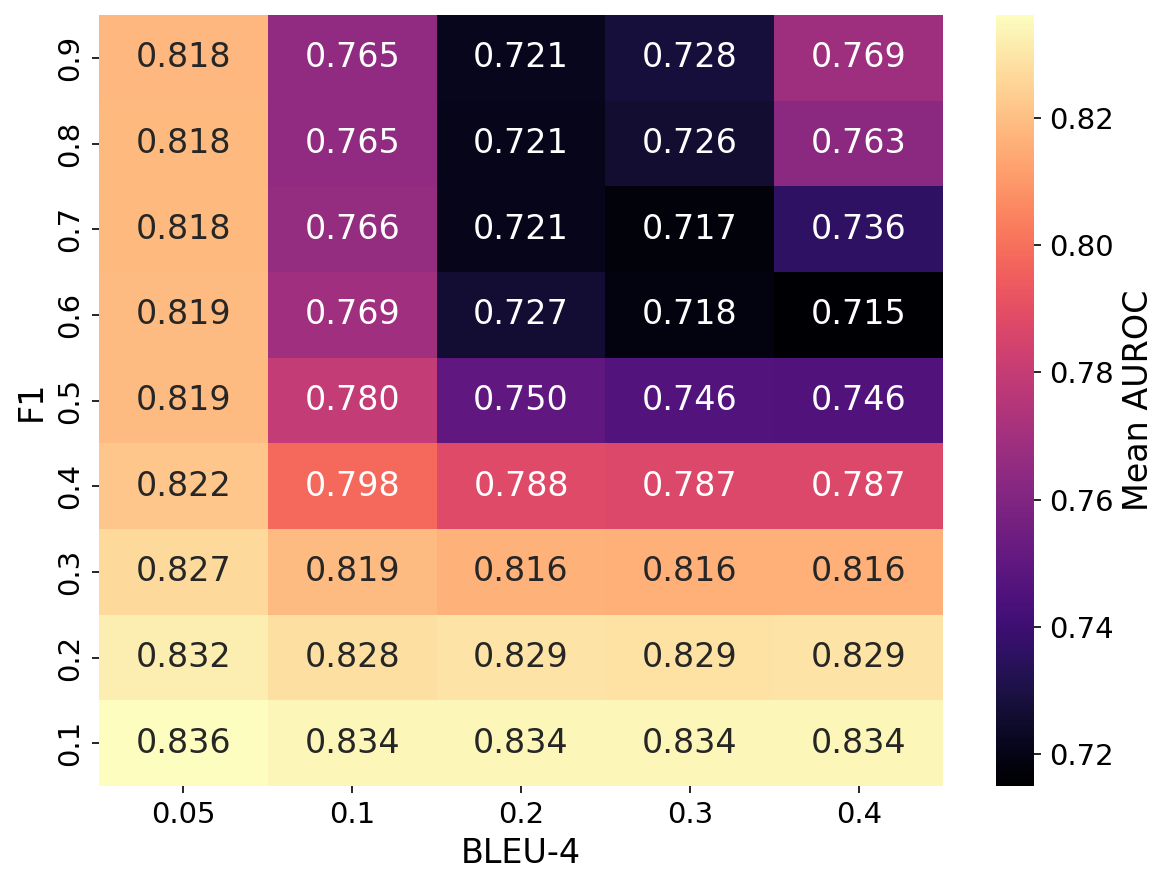

In [84]:
#OR
from glob import glob
import sys
sys.path.append('../src')
import helper

folders = glob('../rebuttal/*/or*')

res = []
for folder in folders:
    model = folder.split('/')[-2]
    comb = folder.split('/')[-1]
    bleu = comb.split('_')[1]
    f1 = comb.split('_')[2]
    try:
        logits = np.load(f'{folder}/logits.npy')
        labels = np.load(f'{folder}/labels.npy')
        m = helper.compute_eval_metrics(logits, labels)
    
        res.append((model, comb, bleu, f1, m['auroc'], m['aupr'], m['brier']))
    except:
        continue

res_df = pd.DataFrame(res, columns=['model', 'comb', 'bleu', 'f1', 'auroc','aupr','brier'])

pivot = res_df.pivot_table(index="f1", columns="bleu", values="auroc", aggfunc="mean")
pivot = pivot.sort_index(ascending=False)

plt.figure(figsize=(8,6), dpi=150)
ax = sns.heatmap(
    pivot,
    annot=True,      
    fmt=".3f",      
    cmap=sns.color_palette("magma", as_cmap=True),
    cbar_kws={"label": "Mean AUROC"},
    annot_kws={"size": 16}
)

cbar = ax.collections[0].colorbar
cbar.set_label("Mean AUROC", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.xlabel("BLEU-4", fontsize=16)
plt.ylabel("F1", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig("../results/figures/Rebuttal_Barrier1_or_combination.pdf", dpi=300, pad_inches=0.0, bbox_inches="tight")
plt.show()